# EDA — DST and Property Crime (CA vs AZ, NV excluded)

Exploratory analysis for the DST and Crime causal analysis project (IDS 701, Duke University, Spring 2026).

**States:** California (DST) vs Arizona (no DST). Nevada excluded.

**Coverage:** Agency reporting consistency, seasonality, hourly crime patterns, DST vs standard time shift, transition fatigue window, and raw parallel trends.

**Note:** All computations are in `scripts/eda/`. Run `python scripts/eda/run_all_eda.py` to regenerate results. This notebook only loads precomputed CSVs from `data/processed/analysis/` and plots them.


In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

_here = Path.cwd()
_root = _here
for _ in range(4):
    if (_root / "data").exists() and (_root / "scripts").exists():
        break
    _root = _root.parent
os.chdir(_root)

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

DATA_DIR = "data/processed/analysis/"
STATES = ["AZ", "CA"]
STATE_COLORS = {"AZ": "#e377c2", "CA": "#1f77b4"}
print("Working dir:", Path.cwd())

Working dir: /Users/shellyy/Desktop/IDS_701/IDS701_UDS_Final_Project


## Section 1 — Agency Reporting Consistency

Shows what fraction of 2024 days each county reported at least one incident. Counties below 80% (red) may introduce attenuation bias — their gaps look like zero crime but are actually missing data.

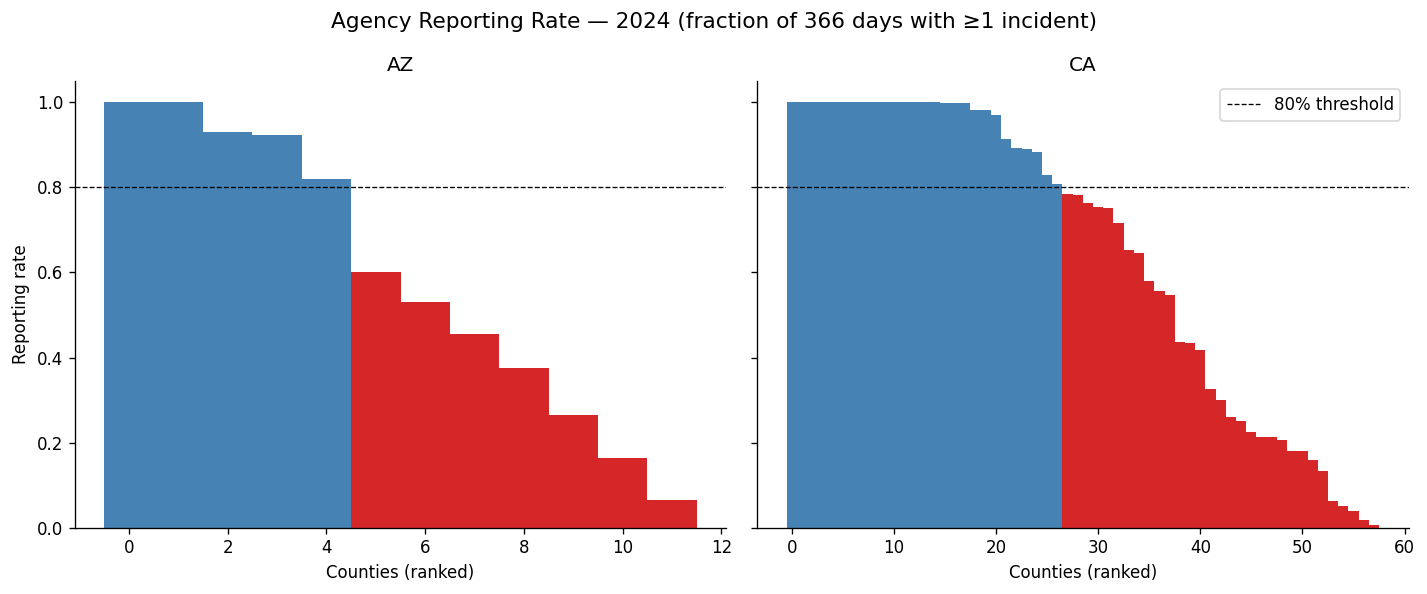

Counties below 80% reporting rate (38 total):
state     county_name  days_reported  reporting_rate
   AZ         YAVAPAI            220        0.601093
   AZ         COCHISE            194        0.530055
   AZ MARICOPA, PINAL            167        0.456284
   AZ            GILA            137        0.374317
   AZ   NOT SPECIFIED             97        0.265027
   AZ          LA PAZ             60        0.163934
   AZ      SANTA CRUZ             24        0.065574
   CA SAN LUIS OBISPO            287        0.784153
   CA        IMPERIAL            286        0.781421
   CA          SUTTER            279        0.762295
   CA          MADERA            276        0.754098
   CA           KINGS            275        0.751366
   CA          SHASTA            262        0.715847
   CA          TEHAMA            239        0.653005
   CA            NAPA            236        0.644809
   CA            LAKE            212        0.579235
   CA       EL DORADO            204        0.557377


In [2]:
cov = pd.read_csv(DATA_DIR + "agency_coverage.csv")
cov = cov[cov["state"].isin(STATES)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle(
    "Agency Reporting Rate — 2024 (fraction of 366 days with ≥1 incident)", fontsize=13
)

for ax, state in zip(axes, STATES):
    sub = (
        cov[cov["state"] == state]
        .sort_values("reporting_rate", ascending=False)
        .reset_index(drop=True)
    )
    colors = ["#d62728" if b else "steelblue" for b in sub["below_80pct"]]
    ax.bar(
        range(len(sub)),
        sub["reporting_rate"],
        color=colors,
        width=1.0,
        edgecolor="none",
    )
    ax.axhline(0.8, color="black", linestyle="--", linewidth=0.8, label="80% threshold")
    ax.set_title(state)
    ax.set_xlabel("Counties (ranked)")
    ax.set_ylim(0, 1.05)
    if ax == axes[0]:
        ax.set_ylabel("Reporting rate")

axes[-1].legend()
plt.tight_layout()
plt.show()

below = cov[cov["below_80pct"]]
print(f"Counties below 80% reporting rate ({len(below)} total):")
print(
    below[["state", "county_name", "days_reported", "reporting_rate"]].to_string(
        index=False
    )
)

## Section 2 — Seasonality and Day-of-Week Patterns

Monthly averages reveal whether crime tracks seasons and whether DST months (March–November) show a structural shift. Day-of-week patterns show the weekend spike common in burglary and motor vehicle theft.

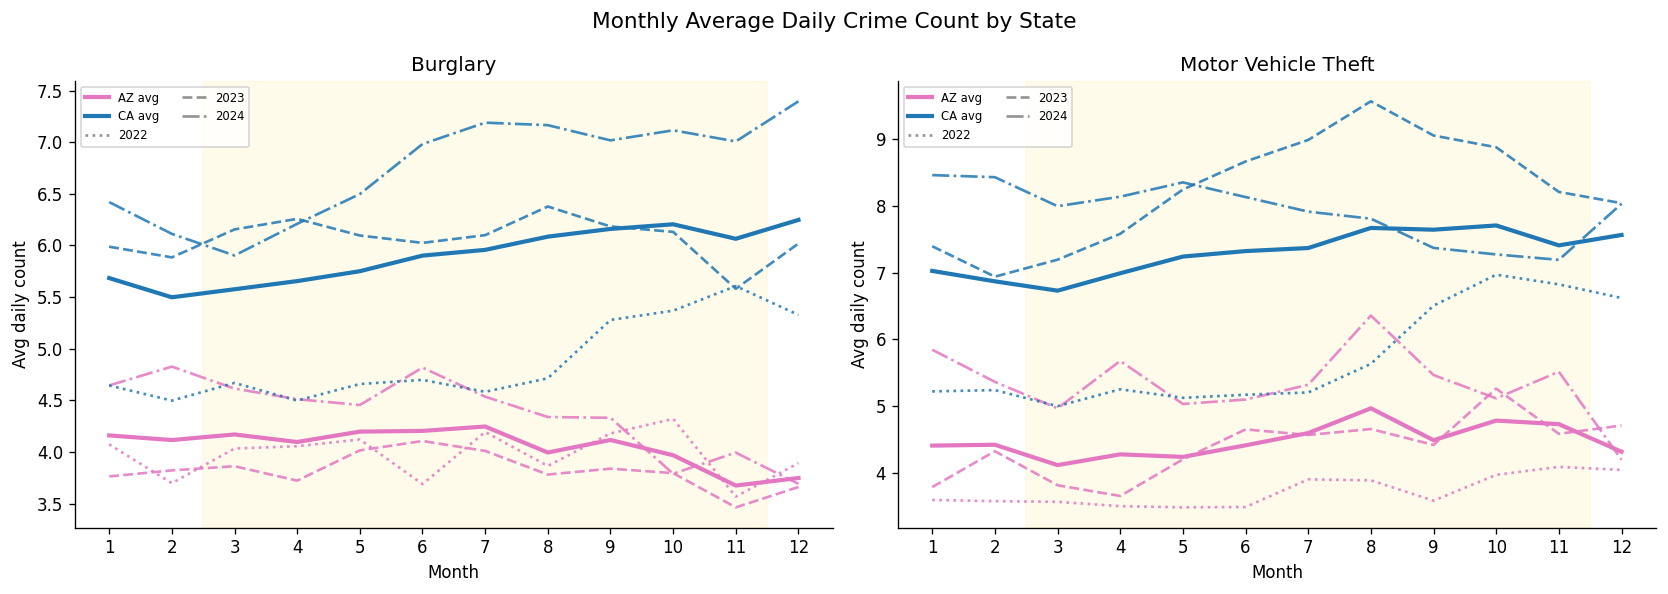

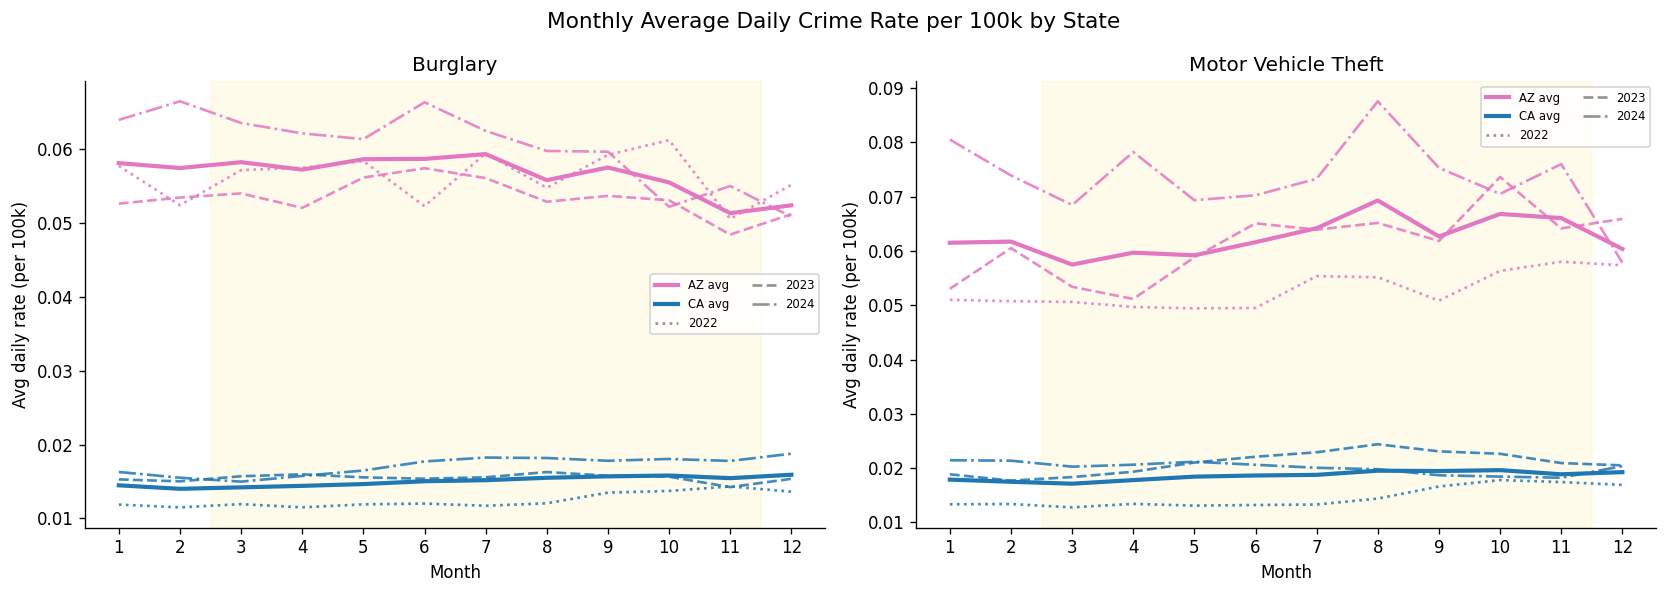

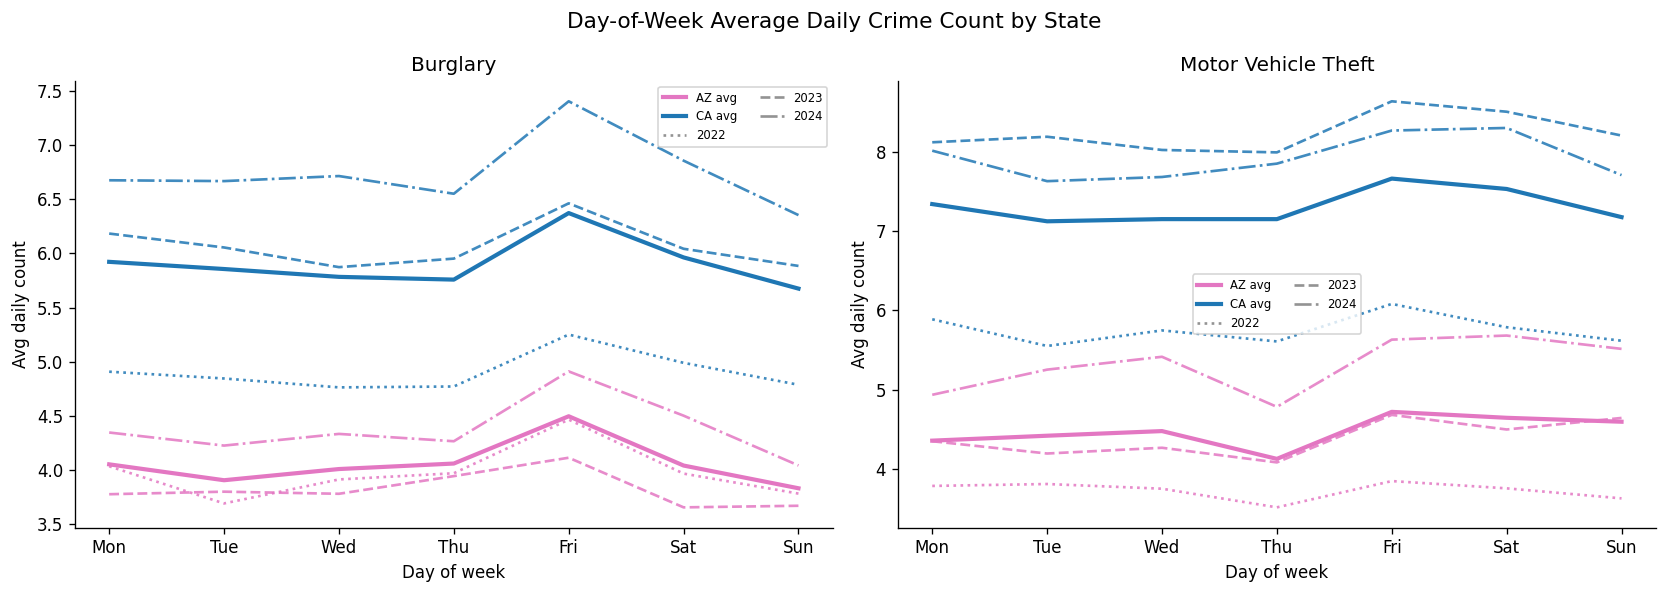

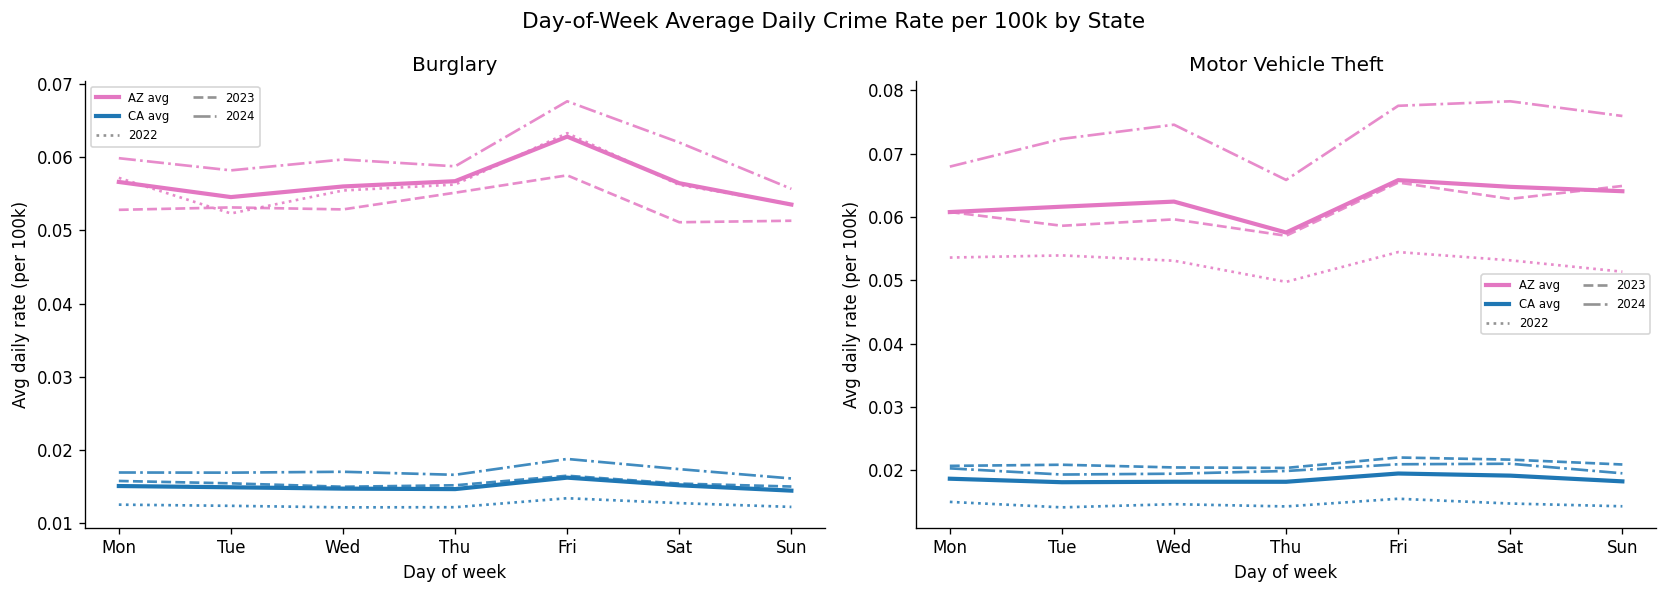

In [3]:
monthly_yr = pd.read_csv(DATA_DIR + "monthly_seasonality_by_year.csv")
monthly = pd.read_csv(DATA_DIR + "monthly_seasonality.csv")
dow_yr = pd.read_csv(DATA_DIR + "dow_pattern_by_year.csv")
dow = pd.read_csv(DATA_DIR + "dow_pattern.csv")

FOCUS_CRIMES = ["burglary", "motor_vehicle_theft"]
DST_MONTHS = list(range(3, 12))
YEAR_STYLES = {
    2022: {"ls": ":", "lw": 1.6, "alpha": 0.85},
    2023: {"ls": "--", "lw": 1.6, "alpha": 0.85},
    2024: {"ls": "-.", "lw": 1.6, "alpha": 0.85},
}
years = sorted(monthly_yr["year"].dropna().unique().astype(int).tolist())


def plot_seasonality(yr_df, avg_df, ycol, ylabel, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Monthly Average Daily Crime {title_suffix} by State", fontsize=13)
    for ax, crime in zip(axes, FOCUS_CRIMES):
        ax.axvspan(2.5, 11.5, alpha=0.08, color="gold", label="DST months")
        for state in STATES:
            for year in years:
                s = yr_df[
                    (yr_df["crime_type"] == crime)
                    & (yr_df["state"] == state)
                    & (yr_df["year"] == year)
                ].sort_values("month")
                st = YEAR_STYLES[year]
                ax.plot(
                    s["month"],
                    s[ycol],
                    color=STATE_COLORS[state],
                    linestyle=st["ls"],
                    linewidth=st["lw"],
                    alpha=st["alpha"],
                    label=f"{state} {year}",
                )
            # All-year average — solid line
            a = avg_df[
                (avg_df["crime_type"] == crime) & (avg_df["state"] == state)
            ].sort_values("month")
            ax.plot(
                a["month"],
                a[ycol],
                color=STATE_COLORS[state],
                linestyle="-",
                linewidth=2.5,
                label=f"{state} avg",
            )
        ax.set_title(crime.replace("_", " ").title())
        ax.set_xlabel("Month")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(1, 13))
        # Legend: one entry per state (avg line) + year lines
        from matplotlib.lines import Line2D

        state_handles = [
            Line2D([0], [0], color=STATE_COLORS[s], lw=2.5, ls="-", label=f"{s} avg")
            for s in STATES
        ]
        year_handles = [
            Line2D(
                [0],
                [0],
                color="gray",
                lw=YEAR_STYLES[y]["lw"],
                ls=YEAR_STYLES[y]["ls"],
                alpha=YEAR_STYLES[y]["alpha"],
                label=str(y),
            )
            for y in years
        ]
        ax.legend(handles=state_handles + year_handles, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_dow(yr_df, avg_df, ycol, ylabel, title_suffix):
    DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Day-of-Week Average Daily Crime {title_suffix} by State", fontsize=13
    )
    for ax, crime in zip(axes, FOCUS_CRIMES):
        for state in STATES:
            for year in years:
                s = yr_df[
                    (yr_df["crime_type"] == crime)
                    & (yr_df["state"] == state)
                    & (yr_df["year"] == year)
                ].sort_values("day_of_week")
                st = YEAR_STYLES[year]
                ax.plot(
                    s["day_of_week"],
                    s[ycol],
                    color=STATE_COLORS[state],
                    linestyle=st["ls"],
                    linewidth=st["lw"],
                    alpha=st["alpha"],
                )
            a = avg_df[
                (avg_df["crime_type"] == crime) & (avg_df["state"] == state)
            ].sort_values("day_of_week")
            ax.plot(
                a["day_of_week"],
                a[ycol],
                color=STATE_COLORS[state],
                linestyle="-",
                linewidth=2.5,
                label=f"{state} avg",
            )
        ax.set_title(crime.replace("_", " ").title())
        ax.set_xlabel("Day of week")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(7))
        ax.set_xticklabels(DAY_LABELS)
        from matplotlib.lines import Line2D

        state_handles = [
            Line2D([0], [0], color=STATE_COLORS[s], lw=2.5, ls="-", label=f"{s} avg")
            for s in STATES
        ]
        year_handles = [
            Line2D(
                [0],
                [0],
                color="gray",
                lw=YEAR_STYLES[y]["lw"],
                ls=YEAR_STYLES[y]["ls"],
                alpha=YEAR_STYLES[y]["alpha"],
                label=str(y),
            )
            for y in years
        ]
        ax.legend(handles=state_handles + year_handles, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


plot_seasonality(monthly_yr, monthly, "avg_daily_count", "Avg daily count", "Count")
plot_seasonality(
    monthly_yr,
    monthly,
    "avg_daily_rate_per_100k",
    "Avg daily rate (per 100k)",
    "Rate per 100k",
)
plot_dow(dow_yr, dow, "avg_daily_count", "Avg daily count", "Count")
plot_dow(
    dow_yr, dow, "avg_daily_rate_per_100k", "Avg daily rate (per 100k)", "Rate per 100k"
)

## Section 3 — Hourly Crime Distribution

Hourly patterns reveal whether burglary peaks during daylight hours while motor vehicle theft peaks late-night — a pattern that DST (shifting the light-dark boundary) could disrupt.

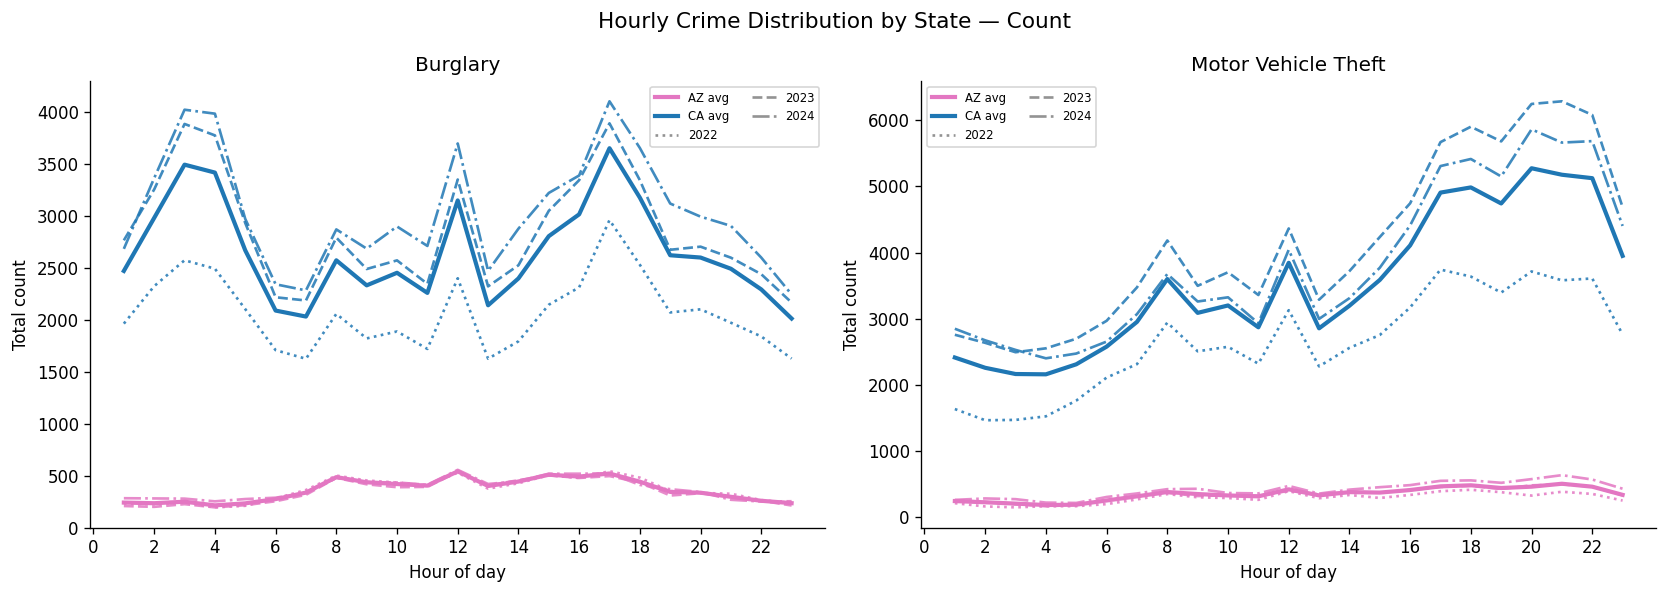

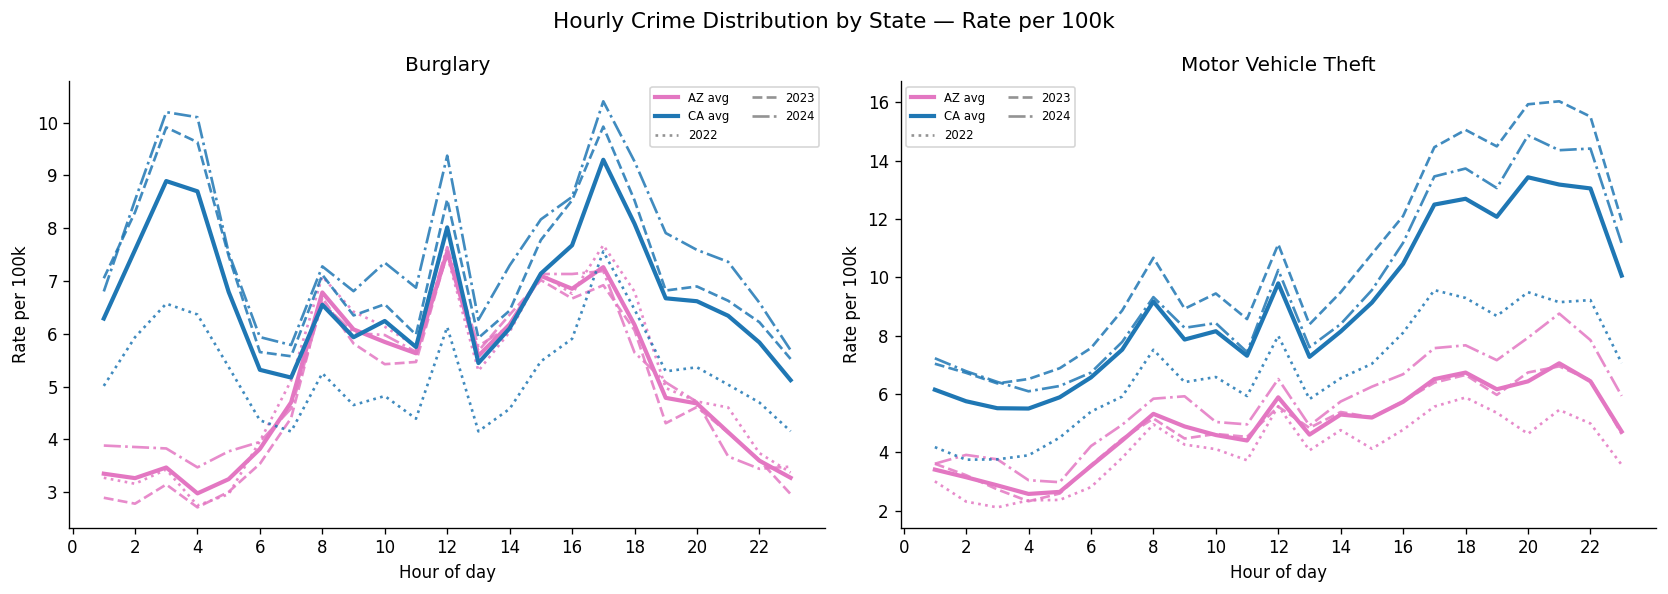

In [4]:
hourly_yr = pd.read_csv(DATA_DIR + "hourly_by_state_by_year.csv")
# All-year average = mean across years (not the summed all-year file)
hourly_avg = (
    hourly_yr.groupby(["state", "hour", "offense_type"])[
        ["crime_count", "crime_rate_per_100k"]
    ]
    .mean()
    .reset_index()
)

FOCUS_CRIMES = ["burglary", "motor_vehicle_theft"]
YEAR_STYLES = {
    2022: {"ls": ":", "lw": 1.6, "alpha": 0.85},
    2023: {"ls": "--", "lw": 1.6, "alpha": 0.85},
    2024: {"ls": "-.", "lw": 1.6, "alpha": 0.85},
}
years_h = sorted(hourly_yr["year"].dropna().unique().astype(int).tolist())


def plot_hourly(yr_df, avg_df, ycol, ylabel, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Hourly Crime Distribution by State — {title_suffix}", fontsize=13)
    for ax, crime in zip(axes, FOCUS_CRIMES):
        for state in STATES:
            for year in years_h:
                s = yr_df[
                    (yr_df["offense_type"] == crime)
                    & (yr_df["state"] == state)
                    & (yr_df["year"] == year)
                ].sort_values("hour")
                st = YEAR_STYLES[year]
                ax.plot(
                    s["hour"],
                    s[ycol],
                    color=STATE_COLORS[state],
                    linestyle=st["ls"],
                    linewidth=st["lw"],
                    alpha=st["alpha"],
                )
            a = avg_df[
                (avg_df["offense_type"] == crime) & (avg_df["state"] == state)
            ].sort_values("hour")
            ax.plot(
                a["hour"],
                a[ycol],
                color=STATE_COLORS[state],
                linestyle="-",
                linewidth=2.5,
                label=f"{state} avg",
            )
        ax.set_title(crime.replace("_", " ").title())
        ax.set_xlabel("Hour of day")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(0, 24, 2))
        from matplotlib.lines import Line2D

        state_handles = [
            Line2D([0], [0], color=STATE_COLORS[s], lw=2.5, ls="-", label=f"{s} avg")
            for s in STATES
        ]
        year_handles = [
            Line2D(
                [0],
                [0],
                color="gray",
                lw=YEAR_STYLES[y]["lw"],
                ls=YEAR_STYLES[y]["ls"],
                alpha=YEAR_STYLES[y]["alpha"],
                label=str(y),
            )
            for y in years_h
        ]
        ax.legend(handles=state_handles + year_handles, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


plot_hourly(hourly_yr, hourly_avg, "crime_count", "Total count", "Count")
plot_hourly(
    hourly_yr, hourly_avg, "crime_rate_per_100k", "Rate per 100k", "Rate per 100k"
)

## Section 4 — DST vs Standard Time Hourly Overlay

Overlaying the DST and standard time hourly distributions directly tests whether the light shift changes when crime occurs — a shift in the peak hour would be consistent with a daylight-driven mechanism.

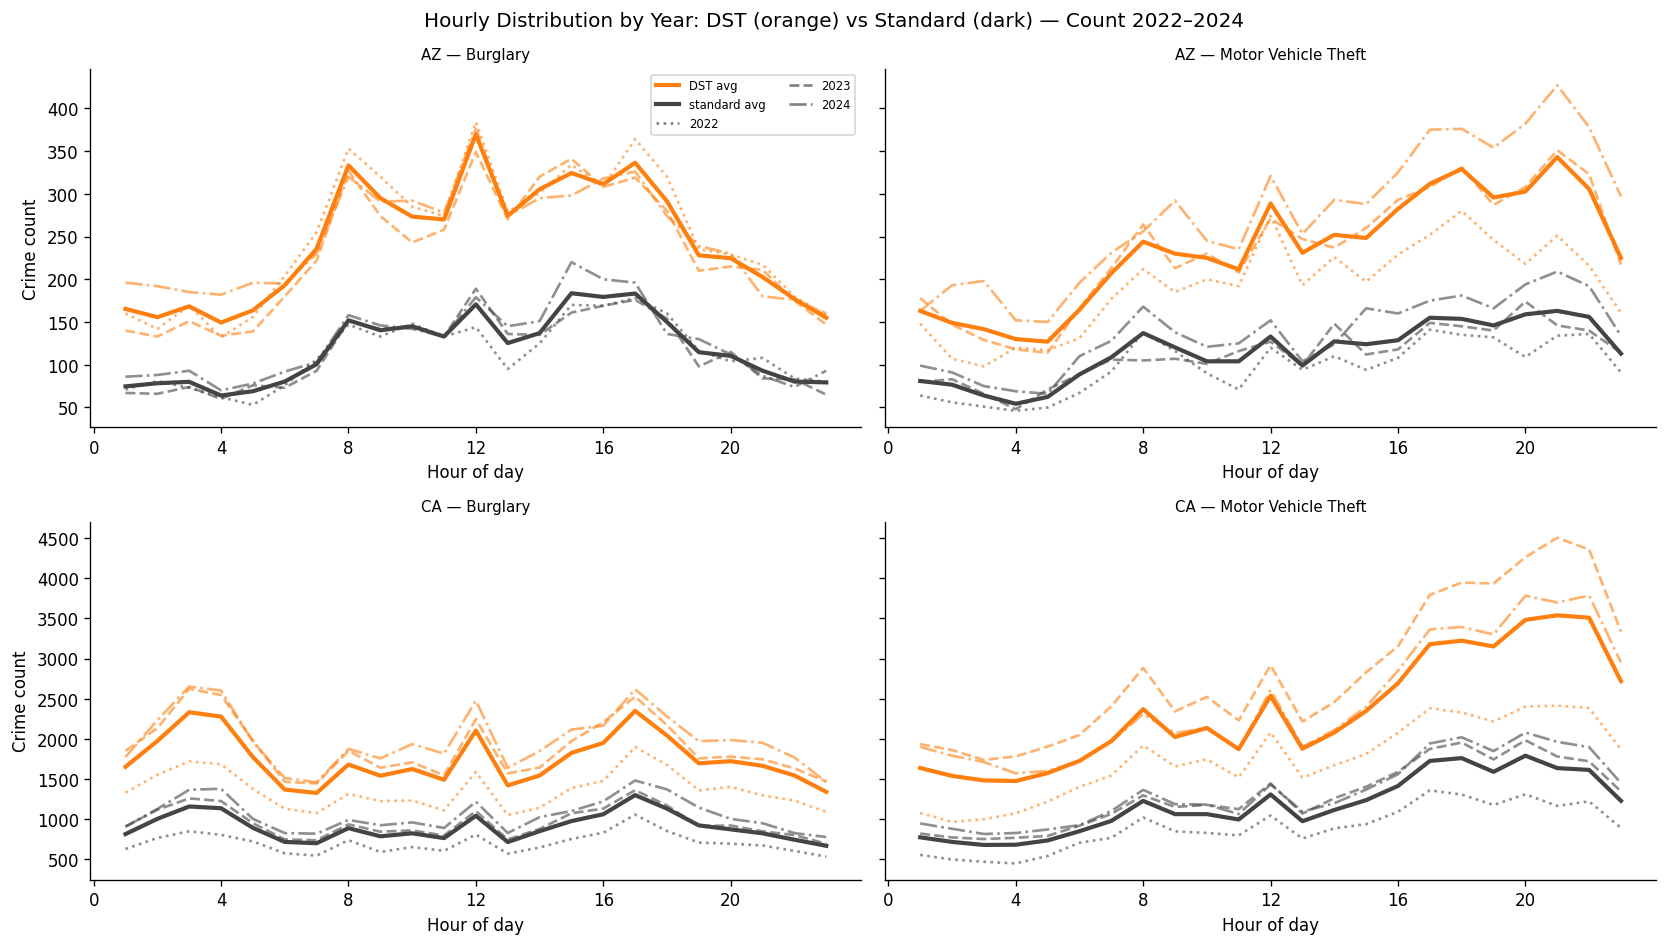

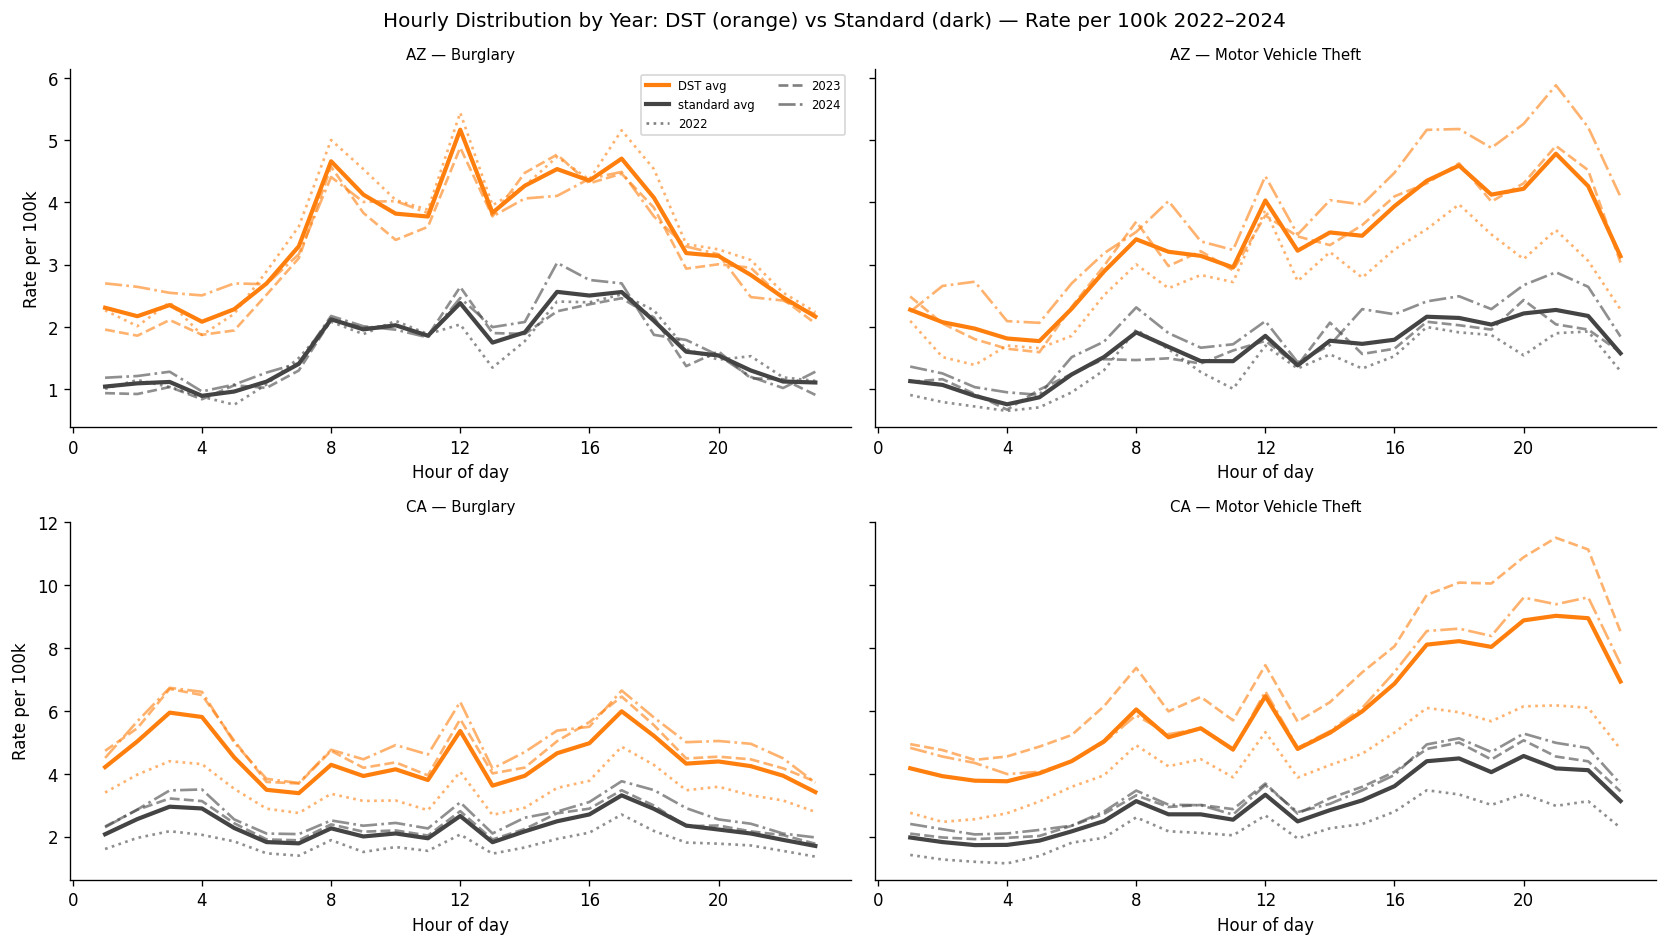

Evening (17–21) and Morning (5–9) shares by state, crime type, period:
                                    evening_share  morning_share
state offense_type        period                                
AZ    burglary            DST               0.229          0.218
                          standard          0.239          0.199
      motor_vehicle_theft DST               0.293          0.180
                          standard          0.292          0.194
CA    burglary            DST               0.235          0.191
                          standard          0.243          0.192
      motor_vehicle_theft DST               0.306          0.179
                          standard          0.313          0.179
NV    burglary            DST               0.184          0.206
                          standard          0.212          0.195
      motor_vehicle_theft DST               0.189          0.260
                          standard          0.199          0.254


In [5]:
period_year_df = pd.read_csv(DATA_DIR + "hourly_by_dst_period_year.csv")
shares_df = pd.read_csv(DATA_DIR + "evening_morning_share.csv")
# All-year average = mean across years per state/crime/hour/period
period_avg = (
    period_year_df.groupby(["state", "hour", "offense_type", "period"])[
        ["crime_count", "crime_rate_per_100k"]
    ]
    .mean()
    .reset_index()
)

FOCUS_CRIMES = ["burglary", "motor_vehicle_theft"]
YEAR_STYLES = {
    2022: {"ls": ":", "lw": 1.6},
    2023: {"ls": "--", "lw": 1.6},
    2024: {"ls": "-.", "lw": 1.6},
}
PERIOD_COLORS = {"DST": "#ff7f0e", "standard": "#444444"}
years = sorted(period_year_df["year"].unique())


def plot_dst_overlay(yr_df, avg_df, ycol, ylabel, title_suffix):
    fig, axes = plt.subplots(
        len(STATES), 2, figsize=(14, 4 * len(STATES)), sharey="row"
    )
    fig.suptitle(
        f"Hourly Distribution by Year: DST (orange) vs Standard (dark) — {title_suffix}",
        fontsize=12,
    )
    for row_i, state in enumerate(STATES):
        for col_i, crime in enumerate(FOCUS_CRIMES):
            ax = axes[row_i][col_i]
            for year in years:
                style = YEAR_STYLES.get(year, {"ls": ":", "lw": 1.2})
                sub = yr_df[
                    (yr_df["state"] == state)
                    & (yr_df["offense_type"] == crime)
                    & (yr_df["year"] == year)
                ]
                for period, color in PERIOD_COLORS.items():
                    s = sub[sub["period"] == period].sort_values("hour")
                    ax.plot(
                        s["hour"],
                        s[ycol],
                        color=color,
                        linewidth=style["lw"],
                        linestyle=style["ls"],
                        alpha=0.6,
                        label=f"{period} {year}",
                    )
            # All-year average — solid line
            for period, color in PERIOD_COLORS.items():
                a = avg_df[
                    (avg_df["state"] == state)
                    & (avg_df["offense_type"] == crime)
                    & (avg_df["period"] == period)
                ].sort_values("hour")
                ax.plot(
                    a["hour"],
                    a[ycol],
                    color=color,
                    linewidth=2.5,
                    linestyle="-",
                    label=f"{period} avg",
                )
            ax.set_title(f'{state} — {crime.replace("_", " ").title()}', fontsize=9)
            ax.set_xticks(range(0, 24, 4))
            ax.set_xlabel("Hour of day")
            if col_i == 0:
                ax.set_ylabel(ylabel)
            if row_i == 0 and col_i == 0:
                from matplotlib.lines import Line2D

                period_h = [
                    Line2D([0], [0], color=c, lw=2.5, ls="-", label=f"{p} avg")
                    for p, c in PERIOD_COLORS.items()
                ]
                year_h = [
                    Line2D(
                        [0],
                        [0],
                        color="gray",
                        lw=YEAR_STYLES[y]["lw"],
                        ls=YEAR_STYLES[y]["ls"],
                        label=str(y),
                    )
                    for y in years
                ]
                ax.legend(handles=period_h + year_h, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


plot_dst_overlay(
    period_year_df, period_avg, "crime_count", "Crime count", "Count 2022–2024"
)
plot_dst_overlay(
    period_year_df,
    period_avg,
    "crime_rate_per_100k",
    "Rate per 100k",
    "Rate per 100k 2022–2024",
)

print("Evening (17–21) and Morning (5–9) shares by state, crime type, period:")
print(
    shares_df.pivot_table(
        index=["state", "offense_type", "period"],
        values=["evening_share", "morning_share"],
    )
    .round(3)
    .to_string()
)

## Section 5 — DST Transition Fatigue Window

Plots daily crime in the 14 days before and after the March 10 spring-forward. A spike or dip immediately after the transition (days 0–3) would suggest a behavioral disruption effect beyond just the light shift.

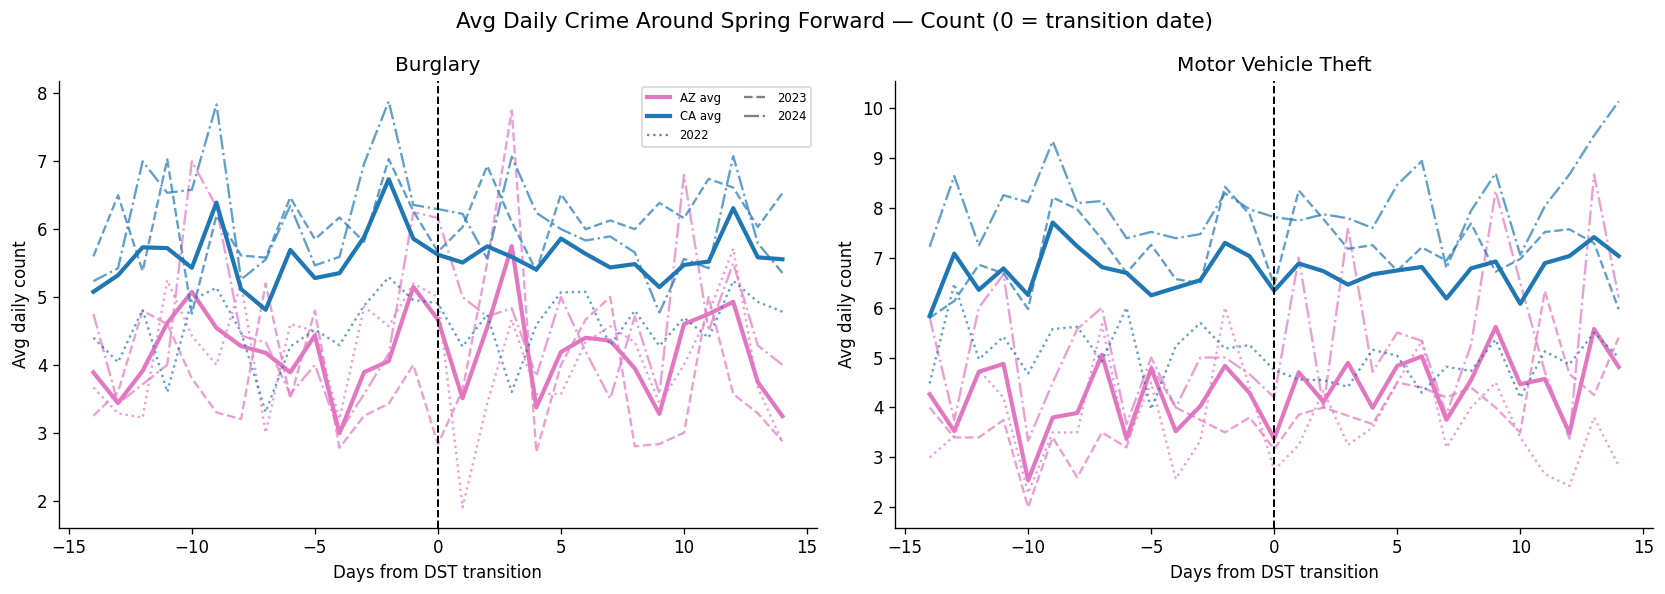

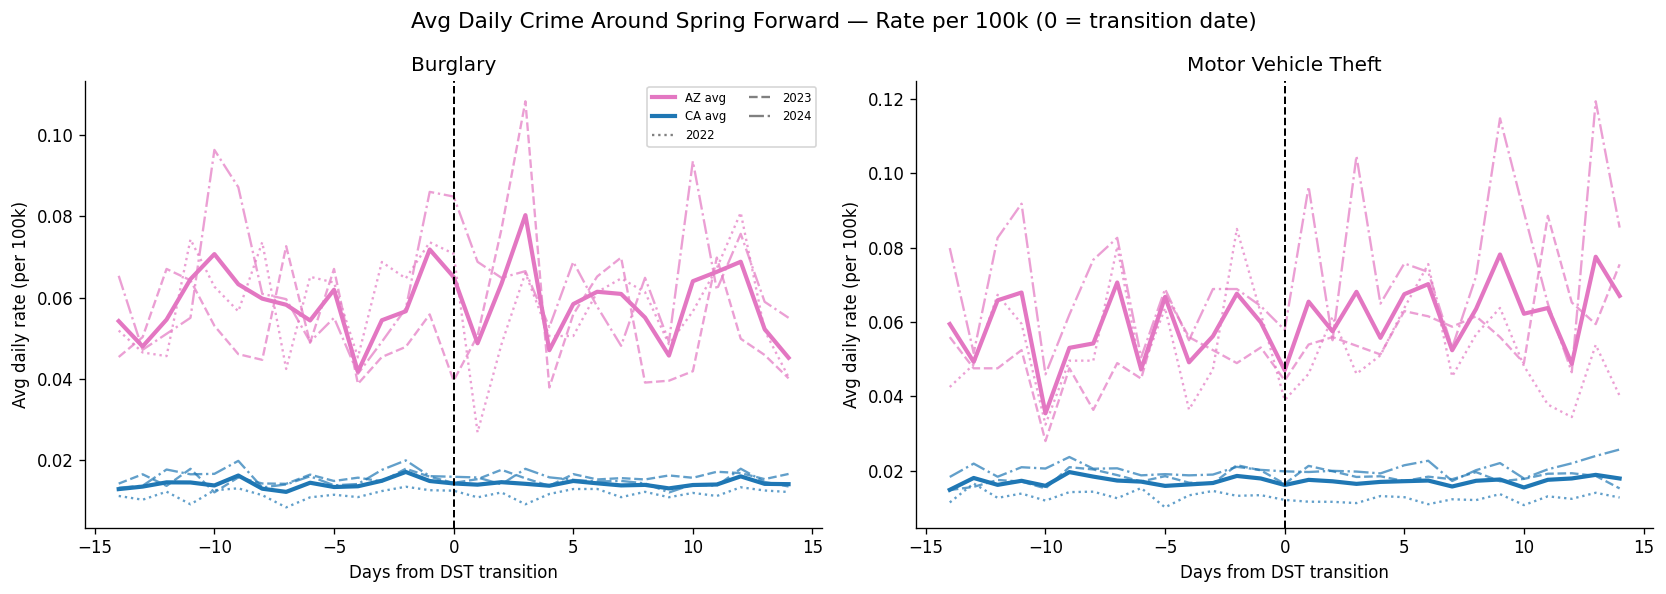

In [6]:
window = pd.read_csv(DATA_DIR + "dst_transition_window.csv")
years = sorted(window["year"].unique())
YEAR_STYLES = {2022: ":", 2023: "--", 2024: "-."}

FOCUS_CRIMES = ["burglary", "motor_vehicle_theft"]


def plot_transition(df, ycol, ylabel, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Avg Daily Crime Around Spring Forward — {title_suffix} (0 = transition date)",
        fontsize=13,
    )
    for ax, crime in zip(axes, FOCUS_CRIMES):
        sub = df[df["crime_type"] == crime]
        for state in STATES:
            for year in years:
                s = sub[(sub["state"] == state) & (sub["year"] == year)].sort_values(
                    "days_from_transition"
                )
                ax.plot(
                    s["days_from_transition"],
                    s[ycol],
                    color=STATE_COLORS[state],
                    linestyle=YEAR_STYLES[year],
                    linewidth=1.4,
                    alpha=0.7,
                )
            # All-year average — solid line
            a = (
                sub[sub["state"] == state]
                .groupby("days_from_transition")[ycol]
                .mean()
                .reset_index()
            )
            ax.plot(
                a["days_from_transition"],
                a[ycol],
                color=STATE_COLORS[state],
                linestyle="-",
                linewidth=2.5,
                label=state,
            )
        ax.axvline(
            0, color="black", linestyle="--", linewidth=1.2, label="Spring forward"
        )
        ax.set_title(crime.replace("_", " ").title())
        ax.set_xlabel("Days from DST transition")
        ax.set_ylabel(ylabel)

    from matplotlib.lines import Line2D

    state_handles = [
        Line2D([0], [0], color=STATE_COLORS[s], lw=2.5, ls="-", label=f"{s} avg")
        for s in STATES
    ]
    year_handles = [
        Line2D([0], [0], color="gray", lw=1.4, ls=YEAR_STYLES[y], label=str(y))
        for y in years
    ]
    axes[0].legend(handles=state_handles + year_handles, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


plot_transition(window, "avg_daily_count", "Avg daily count", "Count")
plot_transition(
    window, "avg_daily_rate_per_100k", "Avg daily rate (per 100k)", "Rate per 100k"
)

## Section 6 — Raw Parallel Trends

Plots state-level mean daily crime rate per 100k residents by month. Parallel pre-trends between treated states (CA, FL, UT) and the control (AZ) are the key identifying assumption — if they diverge only after the March transition, that supports a causal interpretation.

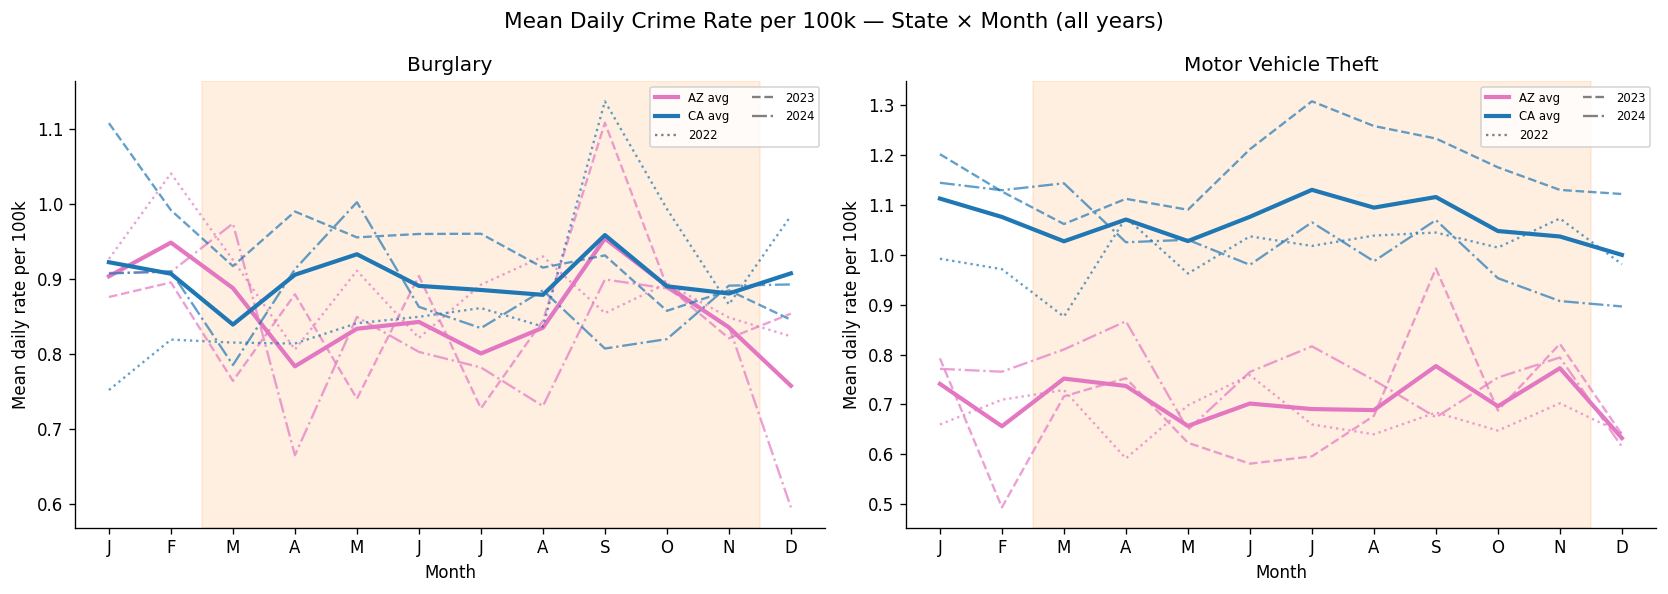

In [7]:
trends = pd.read_csv(DATA_DIR + "parallel_trends_monthly.csv")
years = sorted(trends["year"].unique())
YEAR_STYLES = {2022: ":", 2023: "--", 2024: "-."}

FOCUS_CRIMES = ["burglary", "motor_vehicle_theft"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mean Daily Crime Rate per 100k — State × Month (all years)", fontsize=13)

for col_i, crime in enumerate(FOCUS_CRIMES):
    ax = axes[col_i]
    sub = trends[trends["crime_type"] == crime]

    # DST shading (months 3–11)
    ax.axvspan(2.5, 11.5, alpha=0.12, color="#ff7f0e", zorder=0, label="DST period")

    for state in STATES:
        for year in years:
            s = sub[(sub["state"] == state) & (sub["year"] == year)].sort_values(
                "month"
            )
            ax.plot(
                s["month"],
                s["mean_daily_rate_per_100k"],
                color=STATE_COLORS[state],
                linestyle=YEAR_STYLES[year],
                linewidth=1.4,
                alpha=0.7,
            )
        # All-year average — solid line
        a = (
            sub[sub["state"] == state]
            .groupby("month")["mean_daily_rate_per_100k"]
            .mean()
            .reset_index()
        )
        ax.plot(
            a["month"],
            a["mean_daily_rate_per_100k"],
            color=STATE_COLORS[state],
            linestyle="-",
            linewidth=2.5,
            label=f"{state} avg",
        )

    ax.set_title(crime.replace("_", " ").title())
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_ylabel("Mean daily rate per 100k")

    from matplotlib.lines import Line2D

    state_handles = [
        Line2D([0], [0], color=STATE_COLORS[s], lw=2.5, ls="-", label=f"{s} avg")
        for s in STATES
    ]
    year_handles = [
        Line2D([0], [0], color="gray", lw=1.4, ls=YEAR_STYLES[y], label=str(y))
        for y in years
    ]
    ax.legend(handles=state_handles + year_handles, fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## EDA Summary (CA vs AZ)

This section explored crime patterns across California and Arizona to understand how burglary and motor vehicle theft vary over time and whether simple comparisons between DST and non-DST periods are informative.

---

### Monthly Patterns

- Crime levels are consistently higher during months labeled as DST (March–November)
- This pattern appears in both CA and AZ
- California shows a gradual increase into summer

**Interpretation:**
- The increase during DST months aligns with broader seasonal trends rather than a clear DST-specific shift
- The presence of the same pattern in Arizona (no DST) suggests the difference reflects time-of-year effects, not clock changes

---

### Hourly Patterns

- Burglary tends to peak during daytime and afternoon hours
- Motor vehicle theft peaks in the late afternoon and evening
- These patterns are highly consistent across both states

**Interpretation:**
- Crime follows stable daily routines tied to human activity
- Time-of-day variation is a strong and consistent feature of the data

---

### DST vs Standard Time Comparison

- Crime levels appear higher during DST periods across many hours
- However, Arizona (which never observes DST) shows similar seasonal patterns

**Interpretation:**
- The observed gap between DST and non-DST periods is not unique to DST-observing states
- This suggests that the difference is driven by broader temporal patterns rather than DST alone

---

### Overall Takeaways

- Crime varies strongly by **season (month)** and **time of day (hour)**
- DST periods coincide with higher crime levels, but this pattern is not unique to DST-observing states
- Simple DST vs non-DST comparisons combine multiple effects:
  - seasonal changes
  - weather and activity levels
  - daily behavioral patterns

---

### Transition to Stage 1

The EDA shows that raw comparisons are not sufficient to isolate the role of DST.

In Stage 1, we move to a structured analysis that:
- compares crime within the same state (California)
- incorporates time controls and fixed effects
- examines whether DST-related differences persist after accounting for these patterns

Focus:
- Burglary
- Motor Vehicle Theft
